In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import matplotlib.dates as mdates
from scipy.interpolate import interp1d
from scipy import ndimage
from scipy.stats import linregress

import Functions
import importlib

importlib.reload(Functions)


<module 'Functions' from '/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/Functions/Functions.py'>

In [14]:
app_path = Functions.get_input_path() / 'App'
input_path = app_path / 'Documents' / 'csv' / 'NDVI'

shapes = list(input_path.glob('*.csv'))

path: /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA


In [5]:
df_phen = pd.read_csv('phen_generale.csv', sep=';')
df_phen.drop(columns='Phen', inplace=True)
display(df_phen)

,Date,Code,Phen_PCHIP
0,2017-06-21,1545384,64.000000
1,2017-06-22,1545384,64.430864
2,2017-06-23,1545384,64.854900
3,2017-06-24,1545384,65.260470
4,2017-06-25,1545384,65.635936
...,...,...,...
600,2017-08-14,2278835,78.625287
601,2017-08-15,2278835,79.365602
602,2017-08-16,2278835,80.165177
603,2017-08-17,2278835,81.000000


In [18]:
ratio = pd.read_csv('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/ratio.csv', index_col=0)
display(ratio)

,Date,Code,Name,VH,VV,VH-VV,VH/VV_lin
0,2017-01-04,1545384,DB_SB2_C,-15.490180,-7.163217,-8.326963,0.146995
1,2017-01-04,1553694,DB_SB2_C,-15.392523,-8.082158,-7.310365,0.185765
2,2017-01-04,1576641,HF3_WT_C,-16.767390,-8.279701,-8.487689,0.141655
3,2017-01-04,1601502,RBW_SB,-16.062160,-7.902660,-8.159500,0.152774
4,2017-01-04,1631664,AKW-G1_C,-20.068274,-14.397712,-5.670562,0.270984
...,...,...,...,...,...,...,...
1588,2017-12-30,2081268,RBW_A_C,-14.169023,-7.295080,-6.873944,0.205402
1589,2017-12-30,2081887,SB10_MA_C,-13.969300,-6.683761,-7.285539,0.186830
1590,2017-12-30,2088262,KL_MA_1_C,-17.578556,-11.367661,-6.210895,0.239282
1591,2017-12-30,2278835,PVD-M-C,-13.466336,-6.480057,-6.986279,0.200158


/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


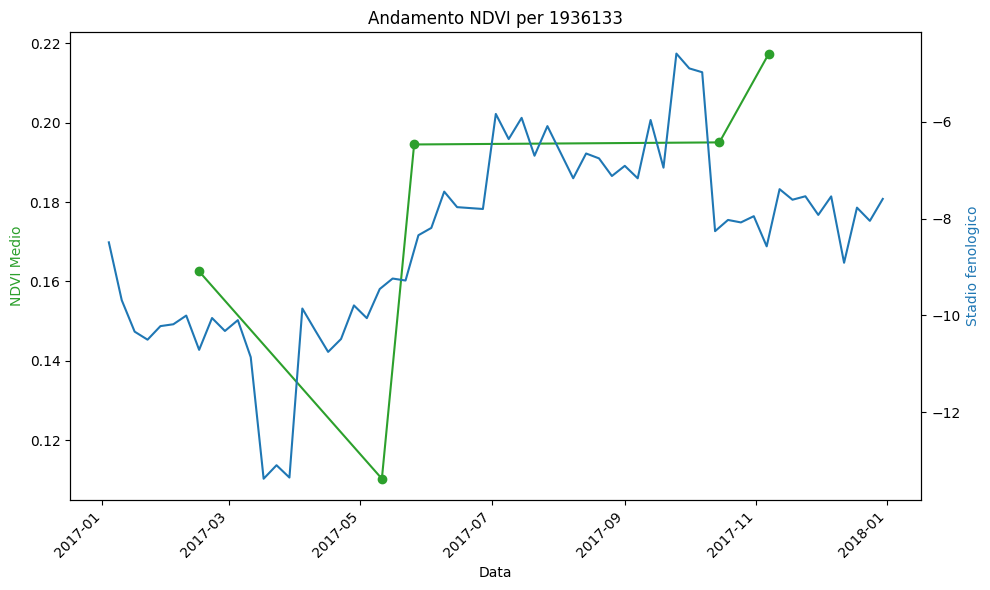

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


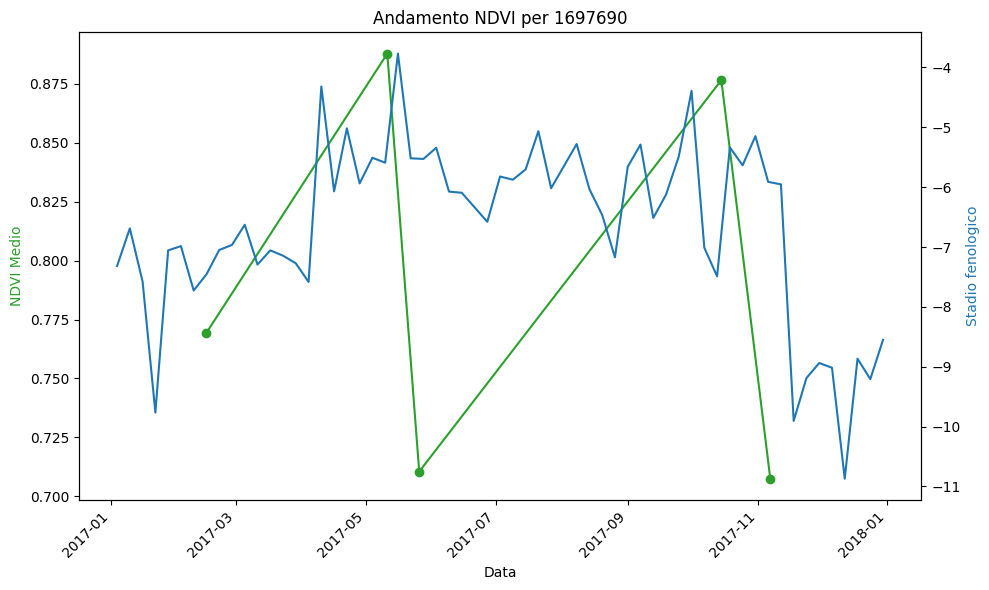

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


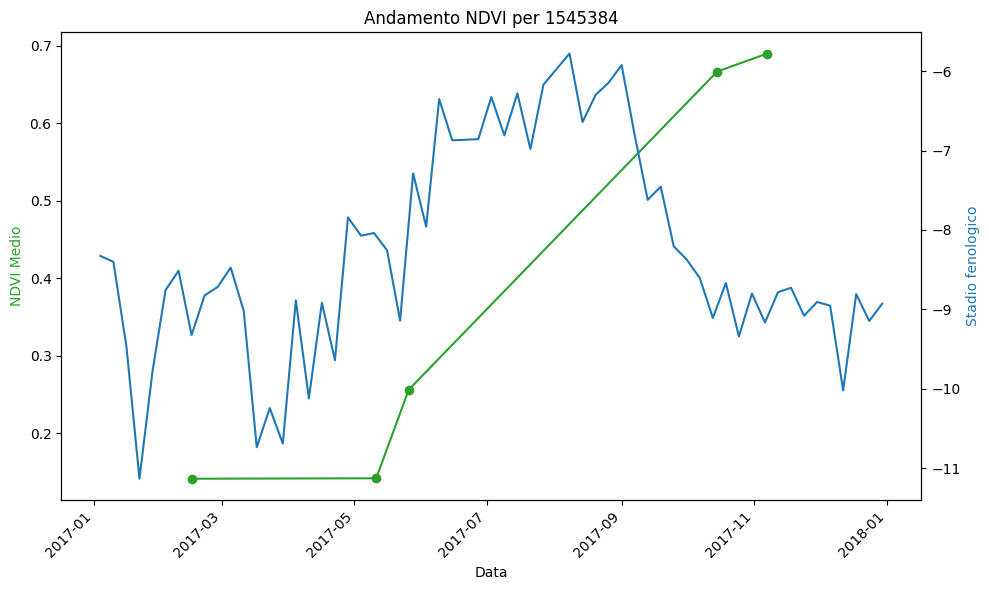

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


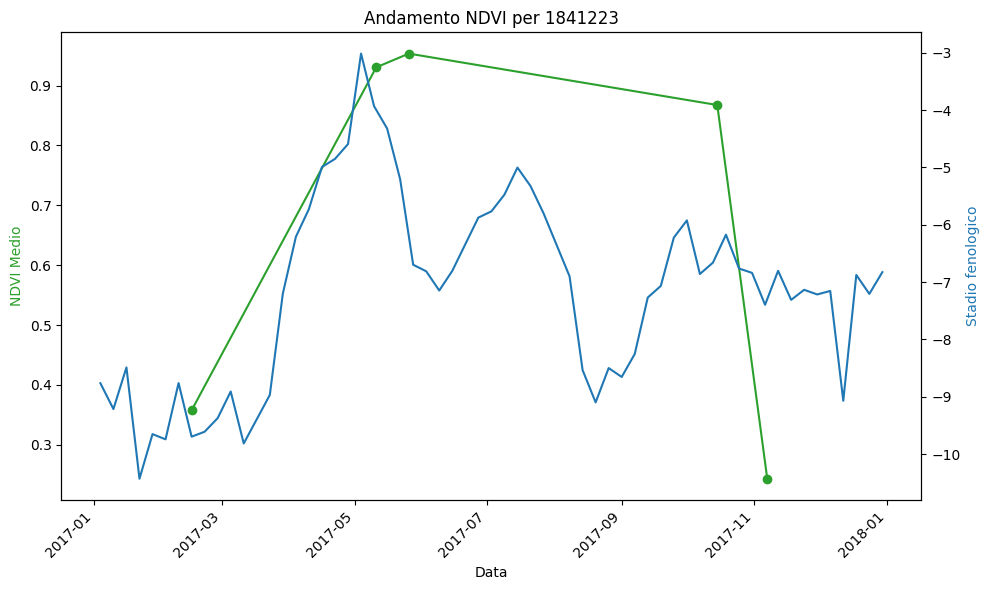

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


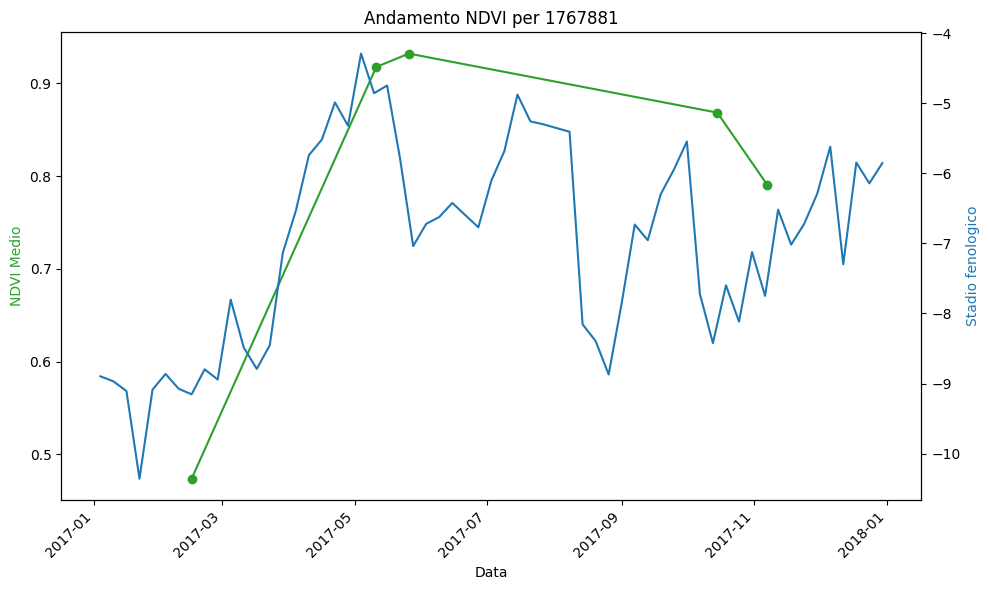

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


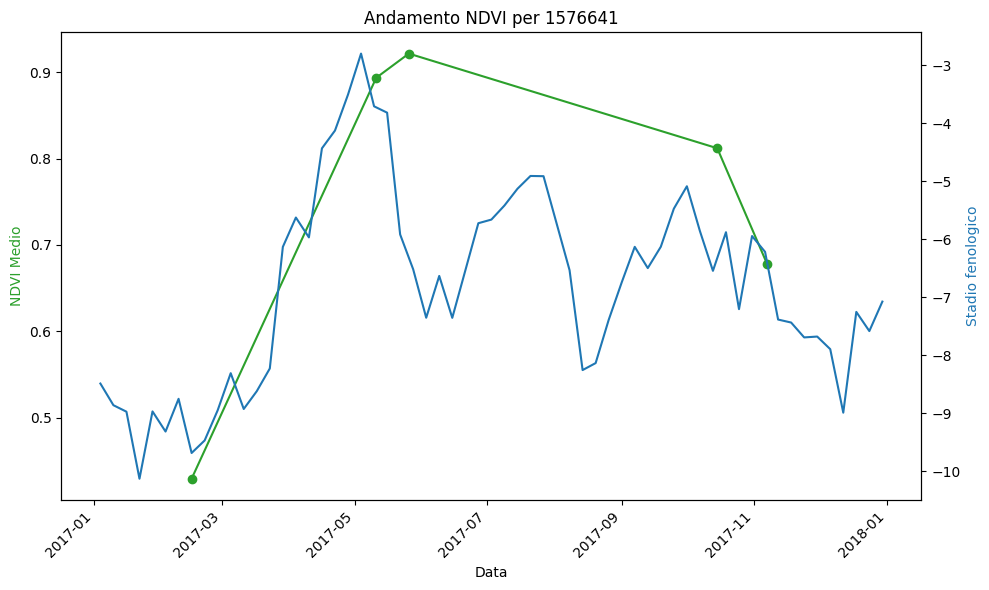

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


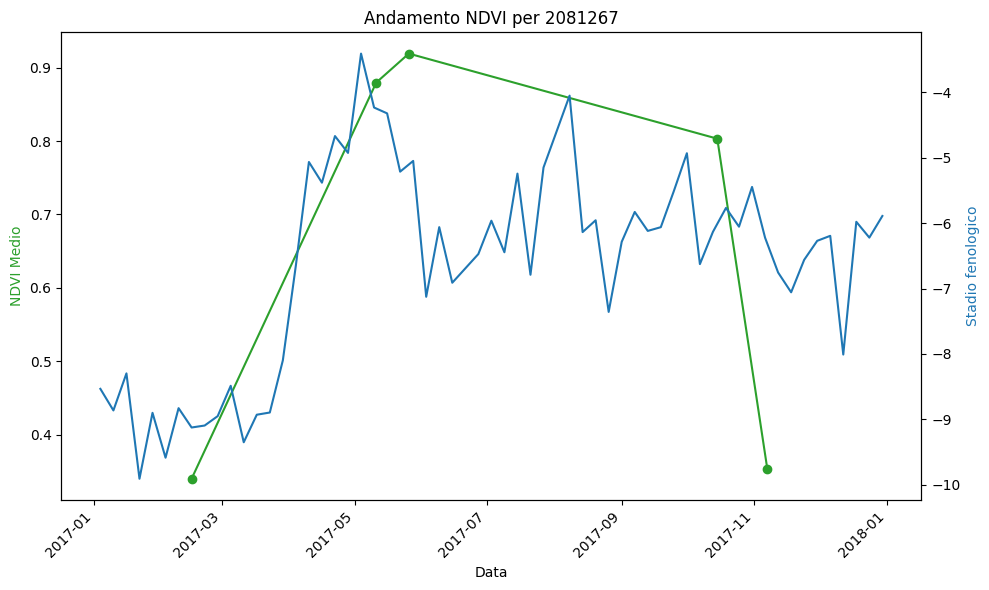

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


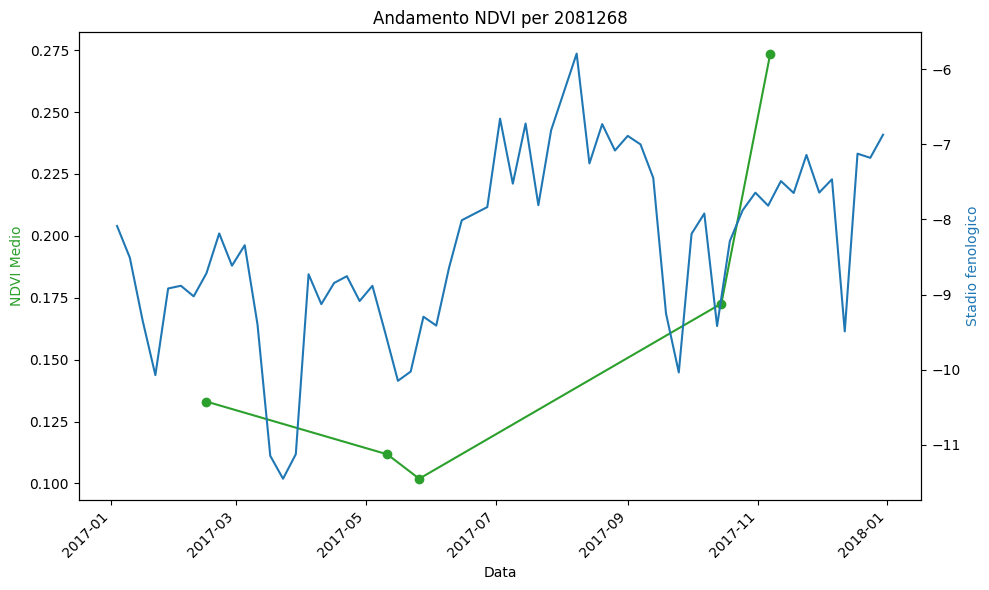

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


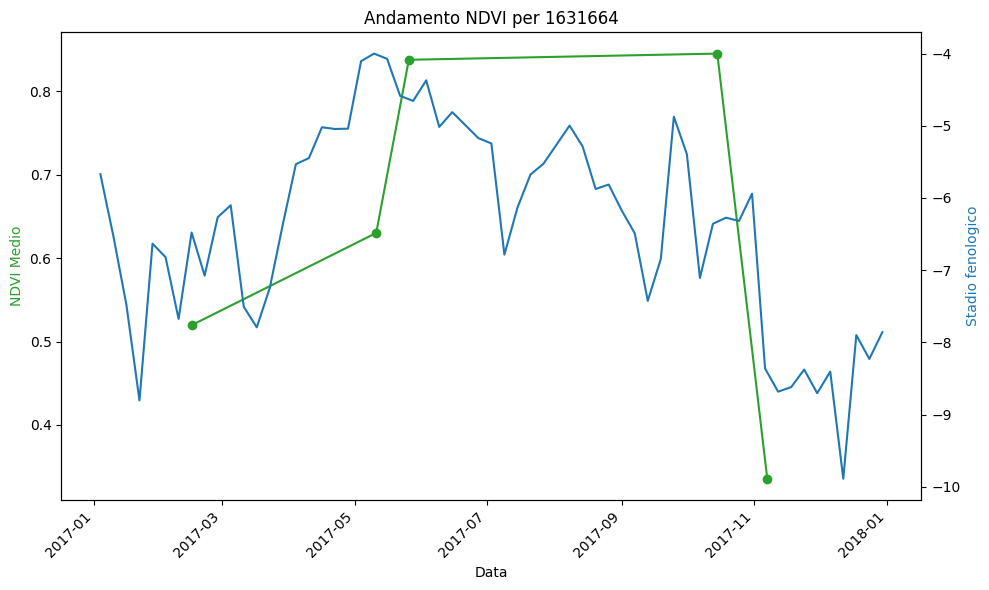

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


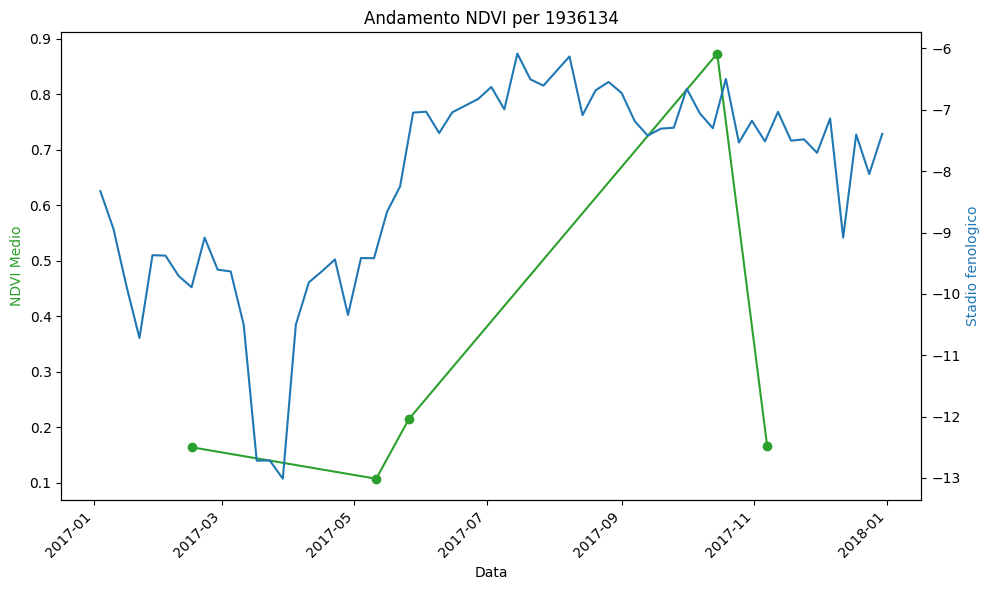

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


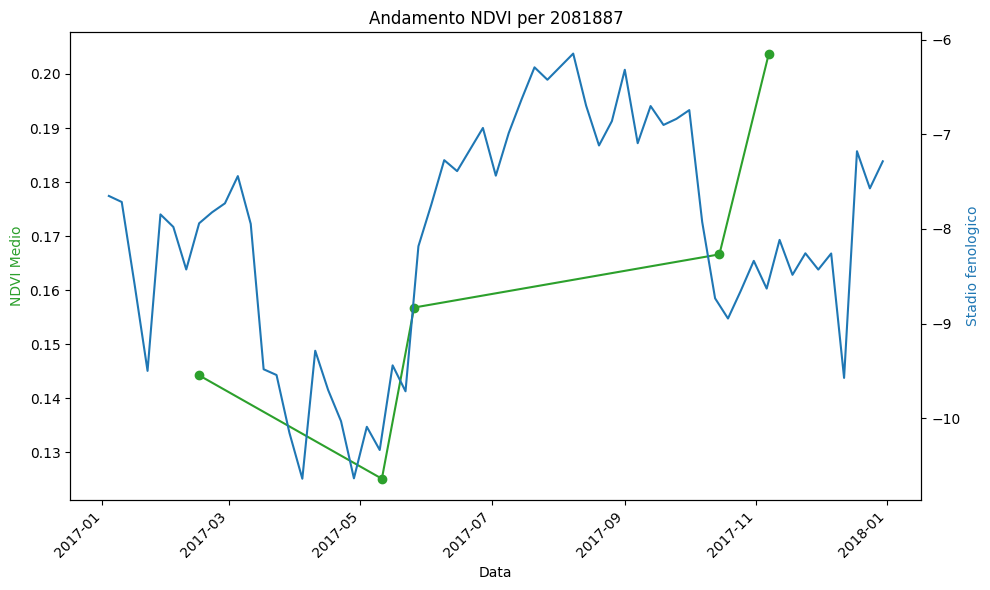

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


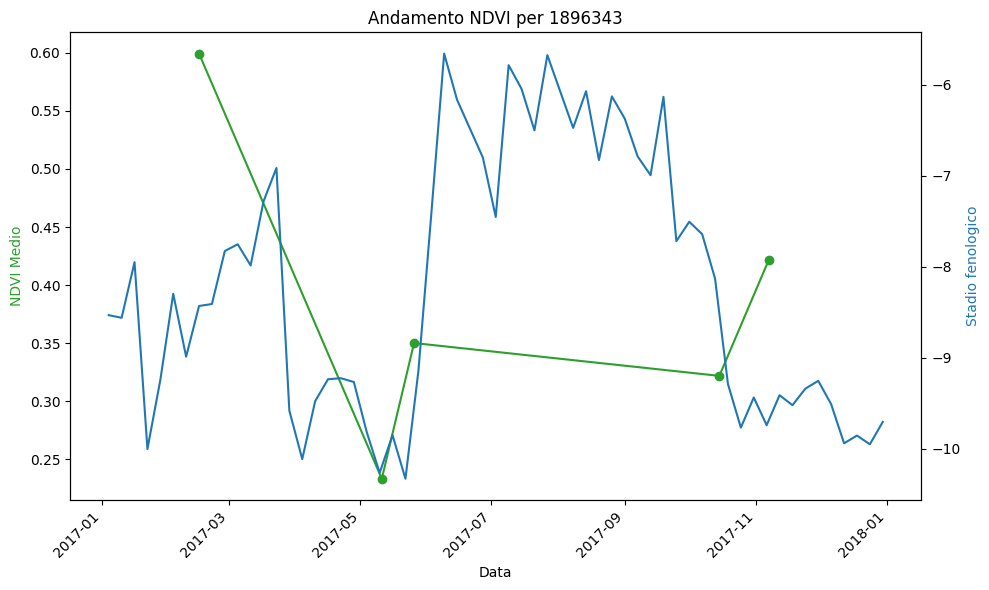

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


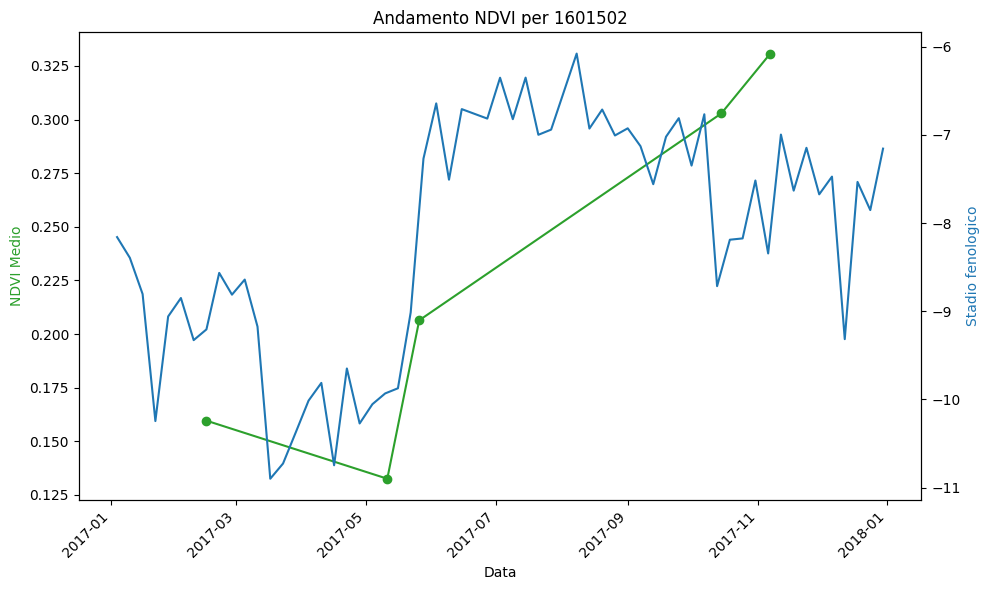

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


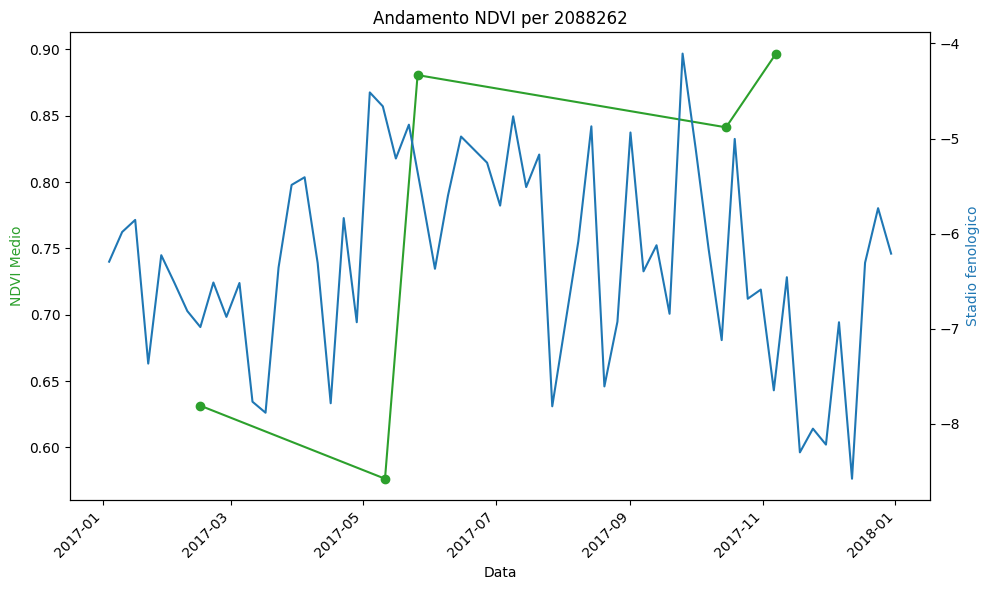

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


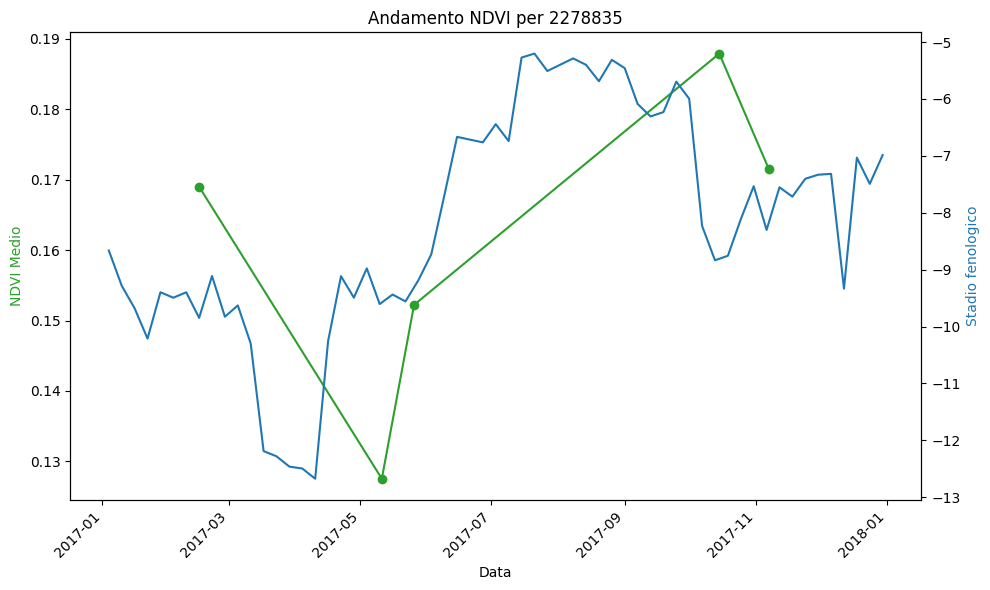

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


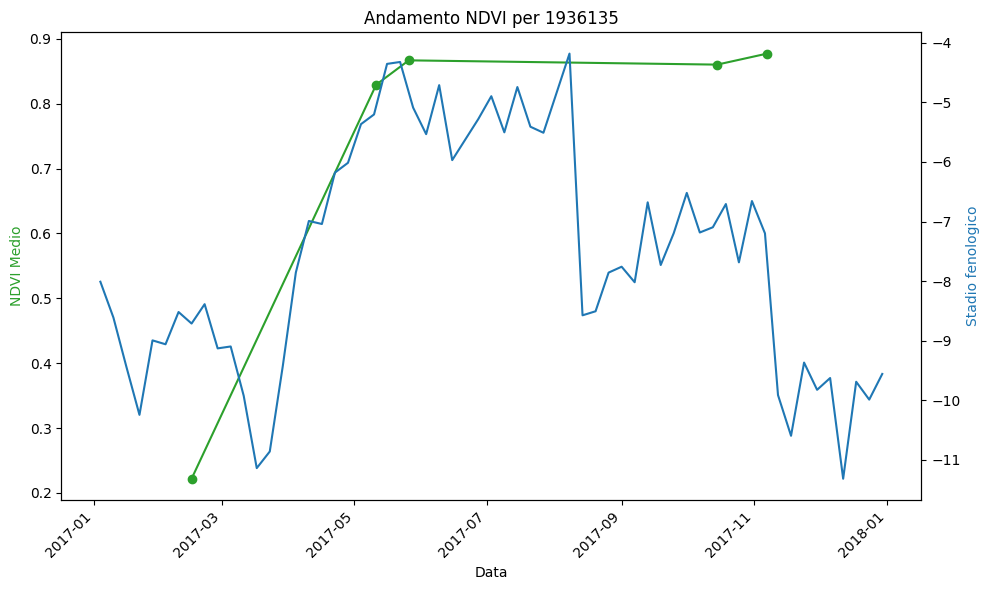

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


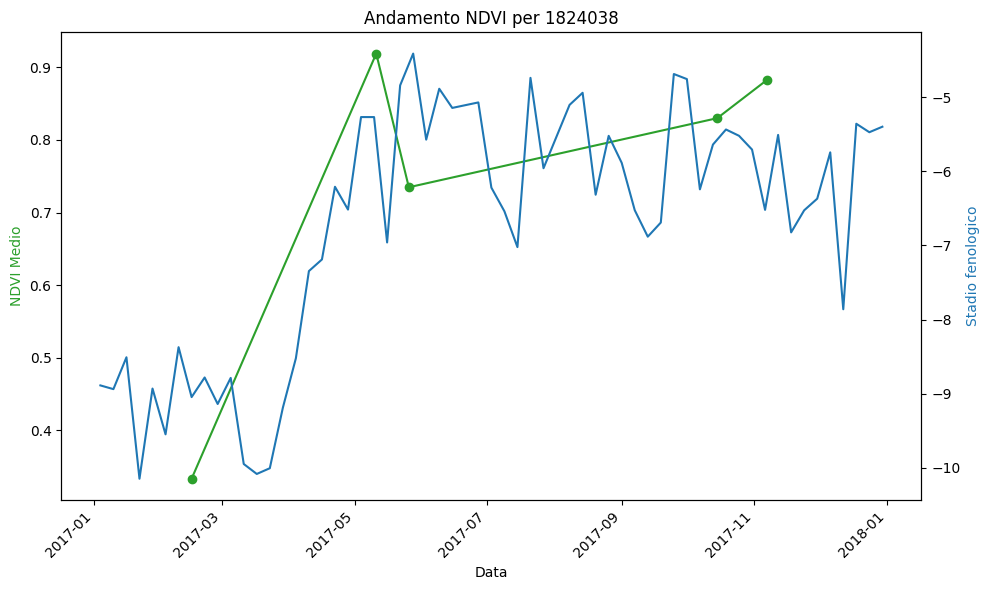

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


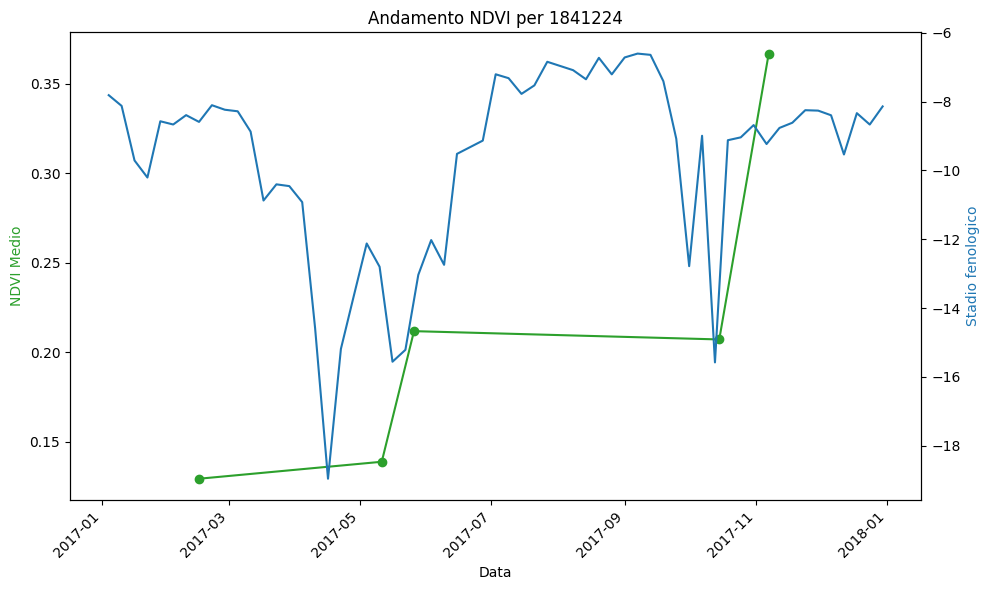

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


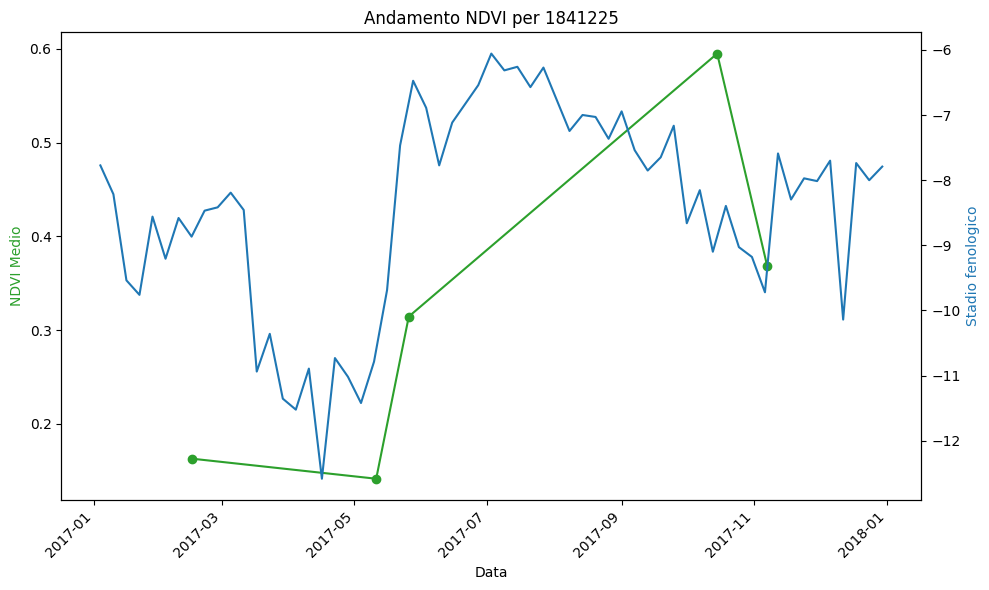

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


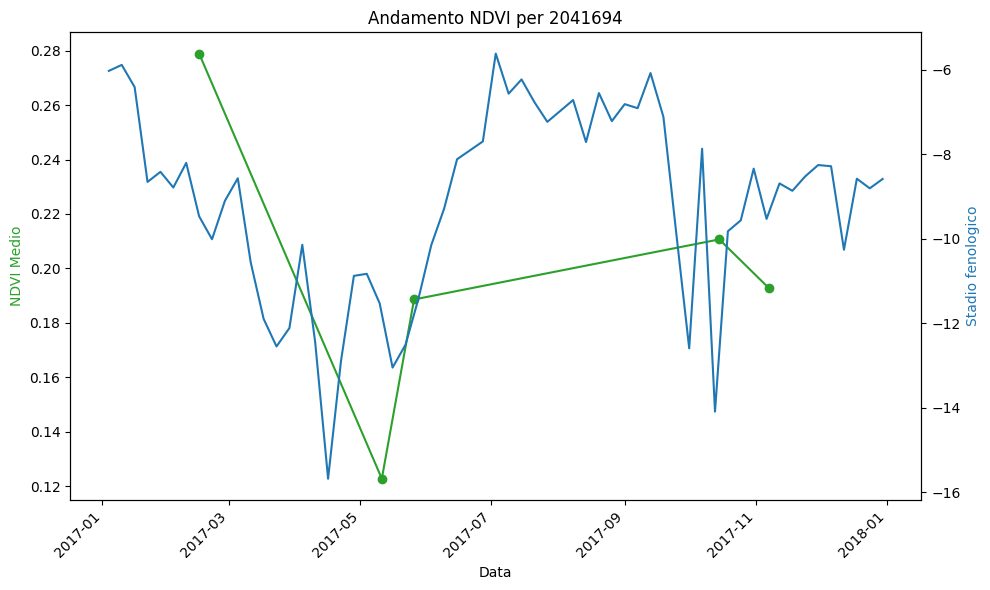

/tmp/ipykernel_22690/905556177.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['Date'] = pd.to_datetime(group['Date'])


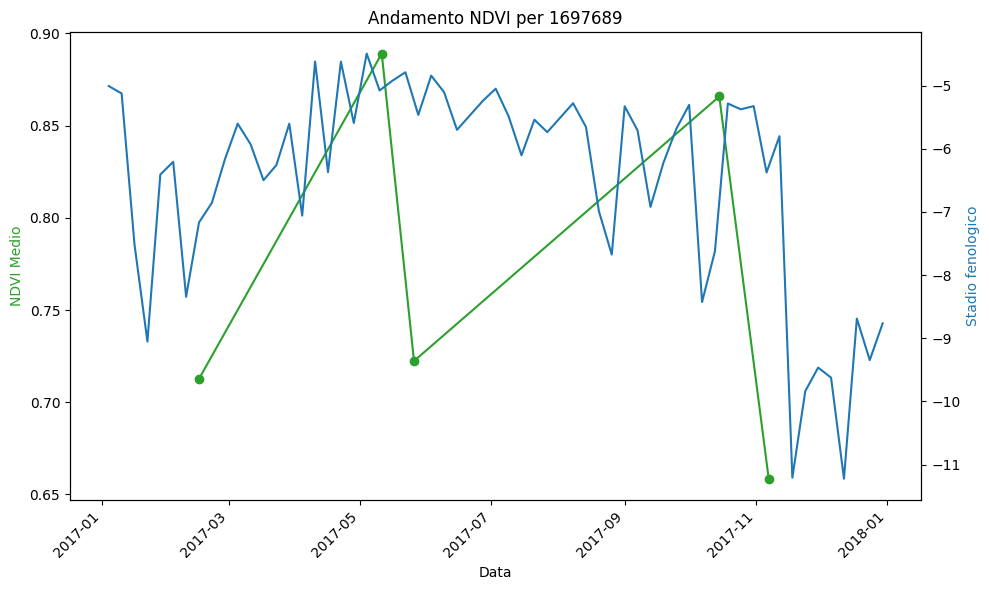

In [19]:
for i in shapes:
    codes = int(i.stem)
    #phen = df_phen[df_phen['Code'] == codes].copy()
    
    group = ratio[ratio['Code'] == codes]


    df = pd.read_csv(i)

    # conversione a datetime vero: fondamentale per allineare l'asse x
    df["Data"]  = pd.to_datetime(df["Data"])
    #phen["Date"] = pd.to_datetime(phen["Date"])
    group['Date'] = pd.to_datetime(group['Date'])

    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(df["Data"], df["NDVI_Medio"], marker="o", linestyle="-", color="tab:green", label="NDVI")
    ax1.set_xlabel("Data")
    ax1.set_ylabel("NDVI Medio", color="tab:green")

    ax2 = ax1.twinx()
   # ax2.plot(phen["Date"], phen["Phen_PCHIP"], linestyle="--", color="tab:blue", label="Fenologia")
    ax2.plot(group['Date'], group['VH-VV'],)
    ax2.set_ylabel("Stadio fenologico", color="tab:blue")

    fig.autofmt_xdate(rotation=45)   # gestisce lui le etichette-data, senza ripetizioni
    plt.title(f"Andamento NDVI per {i.stem}")
    fig.tight_layout()
    plt.show()

In [ ]:
df_height = pd.read_csv(r'/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/Averaged_crop_height.csv', header=0)
df_height.set_index(df_height['Code'].astype(int), inplace=True)
df_height = df_height.drop(columns=['Code'])

date_height = list(pd.to_datetime(df_height.columns))
display(df_height.index)

In [ ]:
serie_1824038 = df_height.loc[1824038.0]
display((list(serie_1824038.index)))

In [46]:
def compare_time_series( dates1, series1, dates2, series2,c=0):
    """
    Compare two time series data sets and calculate the correlation (R²) and RMSE between them.

    The function finds the common date range between two time series, interpolates the second series to match the dates of the first,
    and then computes the correlation and RMSE between them.

    Parameters:
    ----------
    dates1 : list or array
        List or array of dates for the first time series.
    series1 : list or array
        List or array of values for the first time series.
    dates2 : list or array
        List or array of dates for the second time series.
    series2 : list or array
        List or array of values for the second time series.

    Returns:
    -------
    r2 : float
        The R² value (Pearson correlation squared) between the two time series.
    rmse : float
        The RMSE (Root Mean Square Error) between the two time series.
    """
    
    # Find the common date range
    dates1_array = np.array(dates1)
    dates2_array = np.array(dates2)
    start_date = max(dates1_array.min(), dates2_array.min())
    end_date = min(dates1_array.max(), dates2_array.max())

    print(f'Start date: {start_date}\nEnd Date: {end_date}\n')

    # Mask the dates and series to the common range
    mask1 = (dates1_array >= start_date) & (dates1_array <= end_date)
    mask2 = (dates2_array >= start_date) & (dates2_array <= end_date)

    dates1_common = dates1_array[mask1]
    dates1_common.sort()
    s1 = np.squeeze(series1)
    series1_common = s1[mask1]
    print(f'Series1_common/dates1: {series1_common}\n{dates1_common}')
    
    dates2_common = dates2_array[mask2]
    '''
    # Adding previous and following date from the second dates list if necessary
    if start_date not in dates2_array:
        index = np.squeeze(np.where(dates2_array == dates2_common[0]))
        
        if index > 0:
            np.insert(dates2_common, 0, dates2_array[index-1])
    
    if end_date not in dates2_array:
        index = np.squeeze(np.where(dates2_array == dates2_common[-1]))
        
        if index < len(dates2_array) - 1:
            np.insert(dates2_common, -1, dates2_array[index+1])
'''

    dates2_common.sort()
    s2 = np.squeeze(series2)
    series2_common = s2[mask2]
    print(f'Series2_common: {series2_common}\n')



    # Interpolate the data print from the seconds series to match dates of the first series
    dates2_common_numeric = mdates.date2num(dates2_common)
    dates1_common_numeric = mdates.date2num(dates1_common)
    interpolator = interp1d(dates2_common_numeric, series2_common, kind='linear', bounds_error=False, fill_value=np.nan)
    series2_interpolated = interpolator(dates1_common_numeric)
    print(f'series2_interpolated: {series2_interpolated}\n')
    print(f'dates2_common: {dates2_common}\n')

    # Remove NaN values resulting from interpolation or in the input series
    valid_mask = (~np.isnan(series2_interpolated) * ~np.isnan(series1_common))
    series1_final = series1_common[valid_mask]
    series2_final = series2_interpolated[valid_mask]

    
    #plt.plot(series2_final)
    plt.plot(series2_common,color='red')
    plt.xticks(rotation=45) # Ruota il testo di 45 gradi

    # Compute R^2 and RMSE

    slope, intercept, r_value, p_value, std_err = linregress(series1_final, series2_final)

    r2 = r_value**2  # r_value is the Pearson correlation coefficient

    predicted_series2 = slope * series1_final + intercept

    rmse = np.sqrt(np.mean((series2_final - predicted_series2) ** 2))
        
    return r2, rmse    
           

In [ ]:
print(serie_height)

Index(['2017-05-18 00:00:00', '2017-05-23 00:00:00', '2017-05-30 00:00:00',
       '2017-06-08 00:00:00', '2017-06-15 00:00:00', '2017-06-21 00:00:00',
       '2017-06-27 00:00:00', '2017-07-03 00:00:00', '2017-07-06 00:00:00',
       '2017-07-13 00:00:00', '2017-07-17 00:00:00', '2017-07-27 00:00:00',
       '2017-08-02 00:00:00', '2017-08-11 00:00:00', '2017-08-17 00:00:00',
       '2017-08-23 00:00:00', '2017-09-01 00:00:00', '2017-09-07 00:00:00',
       '2017-09-15 00:00:00'],
      dtype='str')


Start date: 2017-05-18 00:00:00
End Date: 2017-09-15 00:00:00

Series1_common/dates1: Code
1576641    0.281923
1576641    0.249684
1576641    0.236958
1576641    0.253758
1576641    0.188314
1576641    0.188720
1576641    0.227821
1576641    0.194299
1576641    0.188645
1576641    0.404210
1576641    0.208111
1576641    0.318423
1576641    0.445230
1576641    0.412205
1576641    0.328535
1576641    0.269249
1576641    0.262385
1576641    0.364653
Name: mean, dtype: float64
[Timestamp('2017-05-22 00:00:00') Timestamp('2017-05-28 00:00:00')
 Timestamp('2017-06-03 00:00:00') Timestamp('2017-06-09 00:00:00')
 Timestamp('2017-06-15 00:00:00') Timestamp('2017-06-27 00:00:00')
 Timestamp('2017-07-03 00:00:00') Timestamp('2017-07-09 00:00:00')
 Timestamp('2017-07-15 00:00:00') Timestamp('2017-07-21 00:00:00')
 Timestamp('2017-07-27 00:00:00') Timestamp('2017-08-08 00:00:00')
 Timestamp('2017-08-14 00:00:00') Timestamp('2017-08-20 00:00:00')
 Timestamp('2017-08-26 00:00:00') Timestamp('2017-09-

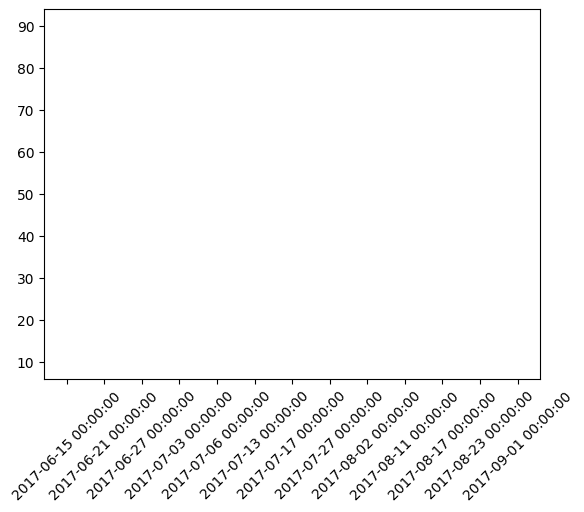

In [47]:
serie_height = df_height.loc[1576641]
serie_S1 = df_stats.loc[[1576641]].query(f"Band == 'VV'")

r2, rmse = compare_time_series(list(pd.to_datetime(date_S1)), 
                                        serie_S1['mean'],
                                        list(pd.to_datetime(serie_height.index)), 
                                        serie_height,1576641)


In [ ]:
polarizzazioni = ['VV', 'VH']
interpolation_results = []

for codes in df_height.index.unique().intersection(df_stats.index):
    for pol in polarizzazioni:

        serie_height = df_height.loc[codes]
        serie_S1 = df_stats.loc[[codes]].query(f"Band == '{pol}'")

        r2, rmse = compare_time_series(list(pd.to_datetime(date_S1)), 
                                        serie_S1['mean'],
                                        list(pd.to_datetime(serie_height.index)), 
                                        serie_height,codes)

        interpolation_results.append({
            'Code': codes,
            'Type': serie_S1['Type'].iloc[0],
            'Pol': pol,
            'R2': r2,
            'rmse': rmse,
            'N_points': len(serie_height.dropna())
        })
df_final_results = pd.DataFrame(interpolation_results)

display(df_final_results.sort_values('R2',ascending=False))
df_final_results.to_csv('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/Regression_JM.csv', index=False)

